# pp_prop: input/output-factorized online gradients

## Goal

Train the same deterministic `braintrace.nn.MiniGRU` task used in the D-RTRL tutorial, changing only the eligibility-trace estimator. `braintrace.ES_D_RTRL` remains a compatibility alias; new code should use `braintrace.pp_prop`.


## 1. What pp_prop factorizes

`pp_prop` carries input-side and output-side eligibility factors instead of a parameter-dimensional trace:

$$
\epsilon^t \approx \epsilon_f^t \otimes \epsilon_x^t,
\qquad
\epsilon_x^t = \alpha\epsilon_x^{t-1} + x^t.
$$

The factorization reduces trace storage from parameter-shaped state toward input/output-dimensional state. It also discards correlations represented by an unfactorized trace, so lower memory does not imply BPTT-equivalent gradients. A floating `decay_or_rank` directly selects the exponential decay; an integer is an alternative parameterization of that decay, not a bank of independently stored rank factors.


## 2. Setup

The seed, model, sequence, optimizer, and number of updates match the D-RTRL walkthrough.


In [1]:
import brainstate
import braintools
import braintrace
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import warnings

brainstate.random.seed(7)

## 3. The matched MiniGRU task

The model is the repository's `braintrace.nn.MiniGRU`, not a separately defined minGRU. Keeping the model and data fixed isolates the effect of the trace factorization.


In [2]:
class SequenceModel(brainstate.nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = braintrace.nn.MiniGRU(in_size=1, out_size=6)
        self.readout = braintrace.nn.Linear(6, 1)

    def update(self, x):
        return self.readout(self.rnn(x))


model = SequenceModel()
inputs = jnp.linspace(-1.0, 1.0, 12).reshape(12, 1, 1)
targets = 0.7 * inputs + 0.2

with warnings.catch_warnings():
    # The Linear readout is intentionally non-temporal; Section 5 explains why.
    warnings.filterwarnings(
        "ignore",
        message=r"ETP primitive etp_mm.*has no connected hidden states.*",
    )
    learner = braintrace.compile(
        model,
        braintrace.pp_prop,
        inputs[0],
        batch_size=1,
        decay_or_rank=0.9,
    )
weights = model.states(brainstate.ParamState)
optimizer = braintools.optim.SGD(lr=0.08)
optimizer.register_trainable_weights(weights);

## 4. Scan factorized traces over the sequence

The training structure is intentionally identical to the D-RTRL notebook. Only the compiler algorithm and its decay are different.


initial loss: 0.0802
epoch  0 loss: 0.0802
epoch 12 loss: 0.0571
epoch 24 loss: 0.0478
final loss: 0.0472
loss decreased: True


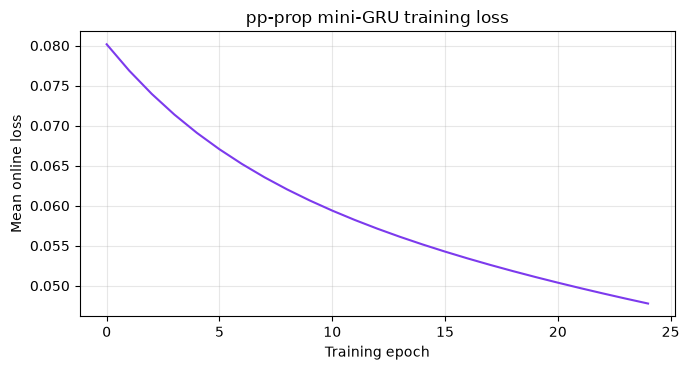

In [3]:
def reset_sequence():
    brainstate.nn.reset_all_states(model, batch_size=1)
    learner.reset_state(batch_size=1)


def evaluate():
    reset_sequence()
    predictions = brainstate.transform.for_loop(learner, inputs)
    return jnp.mean((predictions - targets) ** 2)


def local_loss(x, target):
    prediction = learner(x)
    return jnp.mean((prediction - target) ** 2)


def train_epoch(_):
    reset_sequence()

    def scan_step(accumulated_grads, sample):
        x, target = sample
        step_grads, step_loss = brainstate.transform.grad(
            local_loss, weights, return_value=True
        )(x, target)
        accumulated_grads = jax.tree.map(
            lambda total, current: total + current,
            accumulated_grads,
            step_grads,
        )
        return accumulated_grads, step_loss

    zero_grads = jax.tree.map(jnp.zeros_like, weights.to_dict_values())
    grads, step_losses = brainstate.transform.scan(
        scan_step, zero_grads, (inputs, targets)
    )
    grads = jax.tree.map(lambda grad: grad / inputs.shape[0], grads)
    optimizer.update(grads)
    return step_losses.mean()


initial_loss = evaluate()
training_losses = brainstate.transform.for_loop(
    train_epoch, jnp.arange(25)
)
final_loss = evaluate()

print(f"initial loss: {float(initial_loss):.4f}")
for epoch in (0, 12, 24):
    print(f"epoch {epoch:2d} loss: {float(training_losses[epoch]):.4f}")
print(f"final loss: {float(final_loss):.4f}")
print("loss decreased:", bool(final_loss < initial_loss))

with plt.style.context("default"), plt.rc_context({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
}):
    fig, ax = plt.subplots(figsize=(7, 3.8))
    ax.plot(training_losses, color="#7c3aed")
    ax.set(xlabel="Training epoch", ylabel="Mean online loss")
    ax.set_title("pp-prop mini-GRU training loss")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
plt.show()

## 5. Checks, scope, and limitations

The fixed-seed run should descend, but its final loss need not match D-RTRL. The two estimators retain different information. `decay_or_rank=0.9` is part of the method definition for this run and should be reported with results.

pp_prop is useful beyond rate RNNs. Its input/output-dimensional storage is especially relevant to large spiking networks, provided their learning-signal axis and ETP pathways satisfy the documented contracts. This MiniGRU is a compact API walkthrough, not a replacement for those SNN applications.

A weight that reaches hidden state only through another trainable ETP weight is excluded by the compiler's non-parametric-tail invariant. That exclusion prevents double counting and is not evidence that the optimizer failed.

The scripts listed in `examples/pp_prop/README.md` cover LIF, ALIF, GIF, batching, sparse connectivity, LoRA, convolution, and neuromorphic classification. Those companion scripts retain their task-appropriate SNN models; only this controlled tutorial uses MiniGRU.


## Next steps

- Return to [D-RTRL](drtrl.ipynb) to compare the parameter-dimensional estimator on the same task.
- See [SNN online learning](snn_online_learning.ipynb) for the spiking training workflow.
- See the [algorithm API](../apis/algorithms.rst) for configuration axes and aliases.
